# Regressão Polinomial 

A regressão polinomial é uma extensão da regressão linear que permite modelar relações não-lineares entre as variáveis independentes (features) e a variável dependente (target) ao incluir potências das features como novas características. Em vez de ajustar uma reta, ajusta-se um polinómio de grau d.

## Conceitos matemáticos e de machine learning relacionados:

- **Grau (degree):** o maior expoente $d$ no polinómio. Graus maiores aumentam a flexibilidade do modelo.\
- **Termos polinomiais:** monómios como $x^2$, $x^3$; com múltiplas features aparecem termos cruzados (por exemplo, $x_1 x_2$).\
- **Transformação de features:** criar $X' = [1, x, x^2, ..., x^d]$, onde a coluna `1` corresponde ao intercepto.\
- **Overfitting:** quando o modelo ajusta o ruído dos dados em vez da tendência subjacente (mais provável com grau elevado).\
- **Bias–variance tradeoff:** graus baixos tendem a ter alto bias (subajuste); graus muito altos tendem a ter alta variância (overfitting).\
- **Regularização:** técnicas como `Ridge` e `Lasso` penalizam tamanhos de coeficientes para reduzir overfitting.

## Importar bibliotecas

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid')

### Explicação matemática rápida
A regressão polinomial transforma a(s) feature(s) original(is) em potências e combinações (por exemplo, $x, x^2, x^3, x_1 x_2$) e depois ajusta um modelo linear aos termos transformados.
O objetivo é estimar os coeficientes $\beta$ usando mínimos quadrados (ou com regularização): $\hat{\beta} = argmin_{\beta} ||y - X'\beta||^2$.

## Exemplo 1 — Dados sintéticos (relação polinomial)

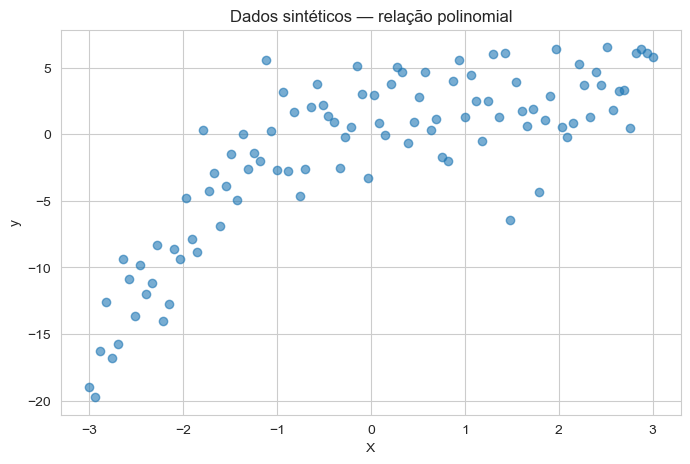

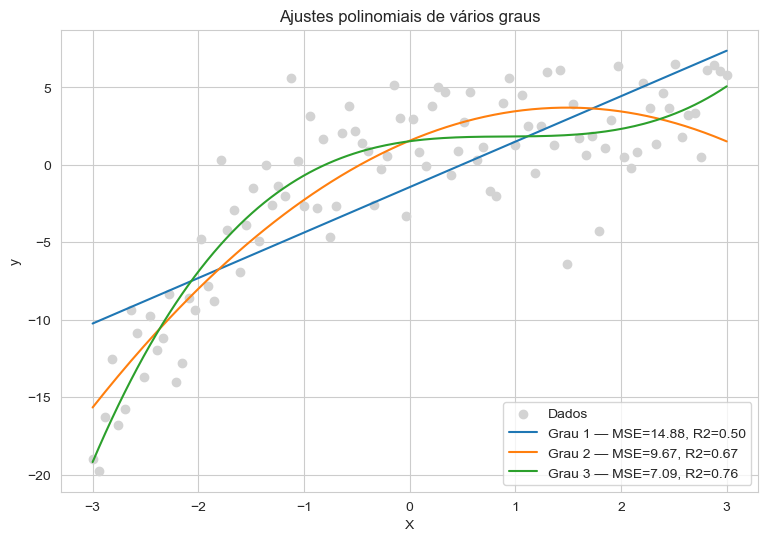

In [ ]:
# Generate synthetic data with a polynomial relationship (degree 3) 
rng = np.random.RandomState(42)
X = np.linspace(-3, 3, 100)[:, None]
y = 0.5 * X.ravel()**3 - 1.0 * X.ravel()**2 + 2.0 + rng.normal(scale=3.0, size=X.shape[0])

# Visualizar
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='tab:blue', alpha=0.6)
plt.title('Dados sintéticos — relação polinomial')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Function to fit and plot polynomial models of various degrees
def fit_and_plot(X, y, degrees=(1,2,3)):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
    X_plot = np.linspace(X.min(), X.max(), 200)[:, None]
    plt.figure(figsize=(9,6))
    plt.scatter(X, y, color='lightgray', label='Dados')
    for deg in degrees:
        poly = PolynomialFeatures(degree=deg)
        X_train_p = poly.fit_transform(X_train)
        X_test_p = poly.transform(X_test)
        model = LinearRegression().fit(X_train_p, y_train)
        y_pred = model.predict(X_test_p)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        y_plot = model.predict(poly.transform(X_plot))
        plt.plot(X_plot, y_plot, label=f'Grau {deg} — MSE={mse:.2f}, R2={r2:.2f}')
    plt.legend()
    plt.title('Ajustes polinomiais de vários graus')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.show()

fit_and_plot(X, y, degrees=(1,2,3))

### Interpretação do Exemplo 1
- O gráfico inicial mostra os pontos amostrados com ruído.
- Ao ajustar modelos de grau 1, 2 e 3, compara-se a capacidade de cada grau em seguir a tendência: grau 1 (reta) costuma subajustar; grau 3 deve aproximar-se bem da função geradora; graus mais altos podem começar a ajustar ruído.
- As métricas MSE e R² mostram numericamente a qualidade do ajuste no conjunto de teste — usar estas métricas para decidir o grau apropriado.

## Exemplo 2 — Usar um ficheiro CSV (ex.: `Datasets/diabetes.csv`)

MSE (degree=2): 0.21474098663684846
R2 (degree=2): 0.06725442071629772


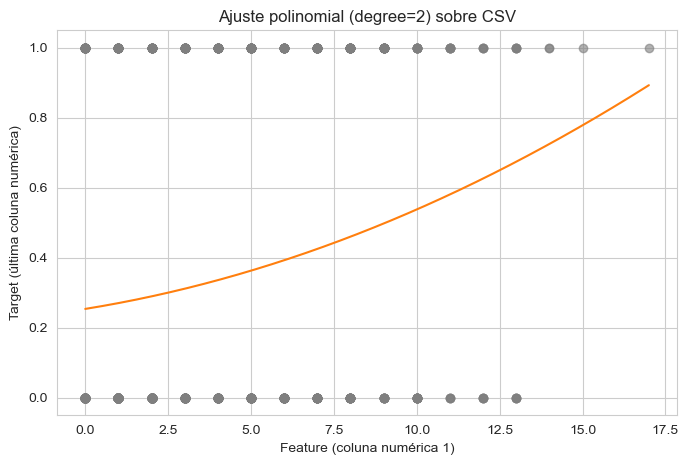

In [ ]:
# Import a CSV from Datasets directory
import os
csv_path = os.path.join('..','Datasets','diabetes.csv')
if not os.path.exists(csv_path):
    csv_path = os.path.join('Datasets','diabetes.csv')

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] < 2:
        print('Ficheiro tem menos de 2 colunas numéricas. Ajuste manualmente as colunas.')
    else:
        # Use the first numeric column as feature and the last as target (generic example) --- IGNORE ---
        X = numeric.iloc[:, [0]].values
        y = numeric.iloc[:, -1].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
        poly = PolynomialFeatures(degree=2)
        X_train_p = poly.fit_transform(X_train)
        X_test_p = poly.transform(X_test)
        model = LinearRegression().fit(X_train_p, y_train)
        y_pred = model.predict(X_test_p)
        print('MSE (degree=2):', mean_squared_error(y_test, y_pred))
        print('R2 (degree=2):', r2_score(y_test, y_pred))
        # Plot simples
        X_plot = np.linspace(X.min(), X.max(), 200)[:, None]
        y_plot = model.predict(poly.transform(X_plot))
        plt.figure(figsize=(8,5))
        plt.scatter(X, y, color='tab:gray', alpha=0.6)
        plt.plot(X_plot, y_plot, color='tab:orange')
        plt.title('Ajuste polinomial (degree=2) sobre CSV')
        plt.xlabel('Feature (coluna numérica 1)')
        plt.ylabel('Target (última coluna numérica)')
        plt.show()
else:
    print('Ficheiro Datasets/diabetes.csv não encontrado no caminho esperado. Coloque o ficheiro na pasta Datasets/ ou ajuste `csv_path`.')

### Interpretação do Exemplo 2
- O notebook usa um exemplo genérico: a primeira coluna numérica como feature e a última como target. Em análises reais, escolha explicitamente colunas significativas.
- Compare sempre o desempenho do modelo polinomial com um modelo linear simples para confirmar ganho real (usar MSE e R² no conjunto de teste).
- Se o polinómio melhora o erro no treino mas piora no teste, é sinal de overfitting; testar `degree` mais baixo ou usar `Ridge`/`Lasso`.

## Prós e Contras da Regressão Polinomial

**Prós:**
- Permite modelar relações não-lineares simples aumentando características polinomiais.
- Mantém o modelo linear nos parâmetros (LinearRegression), o que facilita interpretação e treino.
- Fácil de implementar com `PolynomialFeatures` do scikit-learn.

**Contras:**
- Risco de overfitting para graus elevados.
- Explosão do número de características quando se tem múltiplas variáveis (combinatória).
- Sensível a escala das features — normalizar pode ser necessário.

## Conclusão
A regressão polinomial é uma extensão natural da regressão linear que permite captar curvaturas nas relações entre variáveis. É especialmente útil quando a relação é suave e pode ser bem aproximada por um polinómio de baixo grau. Contudo, exige validação cuidadosa (escolha do grau e uso de regularização) para evitar overfitting. Em cenários de alta dimensão ou comportamentos fortemente não-lineares, considere comparar com modelos mais flexíveis (árvores, ensembles, SVR com kernels, redes neurais) e use validação cruzada para guiar a escolha do modelo.